In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

train_url = "https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/home_loan_train.csv"
test_url = "https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/home_loan_test.csv"

df = pd.read_csv(train_url)
df.head()



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
df_train = df.copy()
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df_train.describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [5]:
df_train.shape

(614, 13)

In [6]:
df_train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
df_train.duplicated().sum()

np.int64(0)

In [8]:
df_train.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [9]:
df_train.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df_train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
df_train.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [12]:
df_train.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [13]:
df_train['ApplicantIncome'] = df_train['ApplicantIncome'].astype(float)

In [14]:
df_train.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [15]:
# for col in df_train.columns:
#     if df_train[col].dtype in ['float64']:
#         df_train[col] = df_train[col].fillna(df_train[col].median())
#     else:
#         df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

float_cols = df_train.select_dtypes(include=['float64']).columns
object_cols = df_train.select_dtypes(exclude=['float64']).columns

fill_values = {
    col: df_train[col].median() for col in float_cols
}
fill_values.update({
    col: df_train[col].mode()[0] for col in object_cols
})

df_train = df_train.fillna(value=fill_values)

In [16]:
df_train.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [17]:
corr = df_train.corr(numeric_only=True)
corr

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,0.011134
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.004705
Credit_History,-0.018615,0.011134,-0.000607,-0.004705,1.000000


In [18]:
numeric_df = df_train.select_dtypes(include='number')
numeric_df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849.0,0.0,128.0,360.0,1.0
1,4583.0,1508.0,128.0,360.0,1.0
2,3000.0,0.0,66.0,360.0,1.0
3,2583.0,2358.0,120.0,360.0,1.0
4,6000.0,0.0,141.0,360.0,1.0


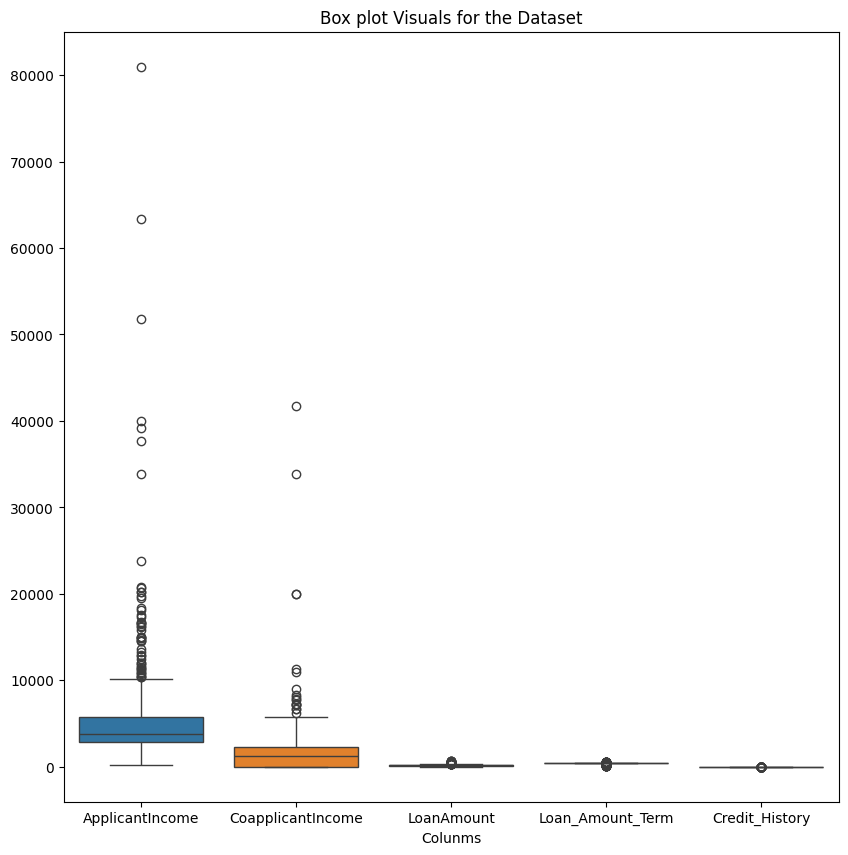

In [19]:
plt.figure(figsize=(10,10))
sns.boxplot(numeric_df)
plt.xlabel("Colunms")
plt.title("Box plot Visuals for the Dataset")
plt.show()

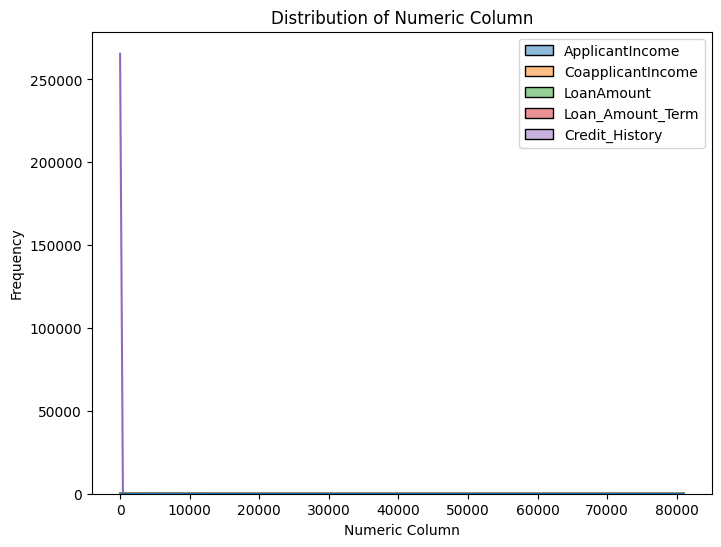

In [20]:
plt.figure(figsize=(8, 6))
sns.histplot(numeric_df, kde=True)
plt.title('Distribution of Numeric Column')
plt.xlabel('Numeric Column')
plt.ylabel('Frequency')
plt.show()

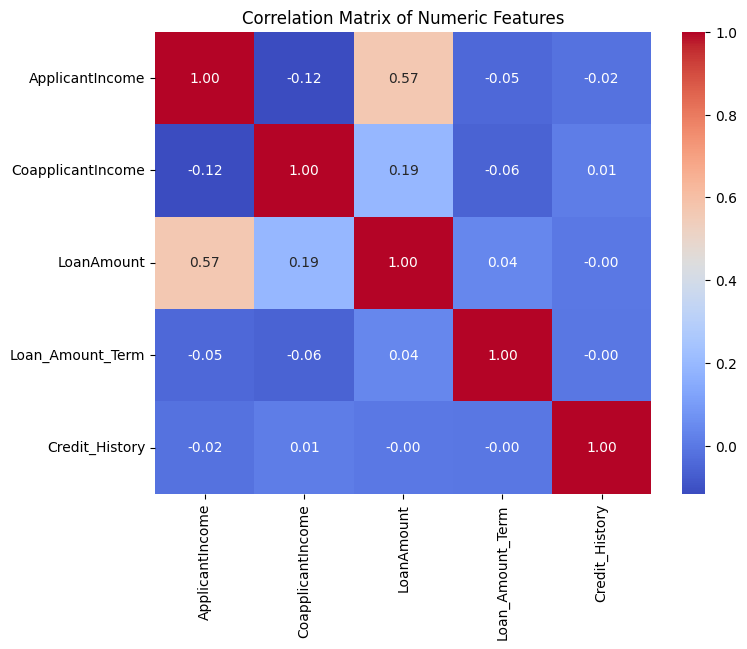

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [22]:
summary = numeric_df.describe(percentiles=[0.10, 0.25, 0.50, 0.75]).T

summary['range'] = summary['max'] - summary['min']
summary['variance'] = numeric_df.var()
summary['skew'] = numeric_df.skew()
summary['mode'] = numeric_df.mode().iloc[0]
summary['coeff_var'] = (summary['std'] / summary['mean']) * 100

summary['IQR'] = summary['75%'] - summary['25%']

summary['Outlier Lower'] = summary['25%'] - 1.5 * summary['IQR']
summary['Outlier Upper'] = summary['75%'] + 1.5 * summary['IQR']
summary['kurtosis'] = numeric_df.kurtosis()

summary = summary.round(3)

print(summary)

                   count      mean       std    min     10%      25%     50%  \
ApplicantIncome    614.0  5403.459  6109.042  150.0  2216.1  2877.50  3812.5   
CoapplicantIncome  614.0  1621.246  2926.248    0.0     0.0     0.00  1188.5   
LoanAmount         614.0   145.752    84.107    9.0    72.3   100.25   128.0   
Loan_Amount_Term   614.0   342.410    64.429   12.0   300.0   360.00   360.0   
Credit_History     614.0     0.855     0.352    0.0     0.0     1.00     1.0   

                       75%      max    range      variance   skew    mode  \
ApplicantIncome    5795.00  81000.0  80850.0  3.732039e+07  6.540  2500.0   
CoapplicantIncome  2297.25  41667.0  41667.0  8.562930e+06  7.492     0.0   
LoanAmount          164.75    700.0    691.0  7.074027e+03  2.743   128.0   
Loan_Amount_Term    360.00    480.0    468.0  4.151048e+03 -2.402   360.0   
Credit_History        1.00      1.0      1.0  1.240000e-01 -2.022     1.0   

                   coeff_var      IQR  Outlier Lower  Ou

In [23]:
loan_amount = df_train["LoanAmount"]
loan_amount_mean = loan_amount.mean()
loan_amount_median = loan_amount.median()
loan_amount_mode = loan_amount.mode()[0]
loan_amount_skew = loan_amount.skew()

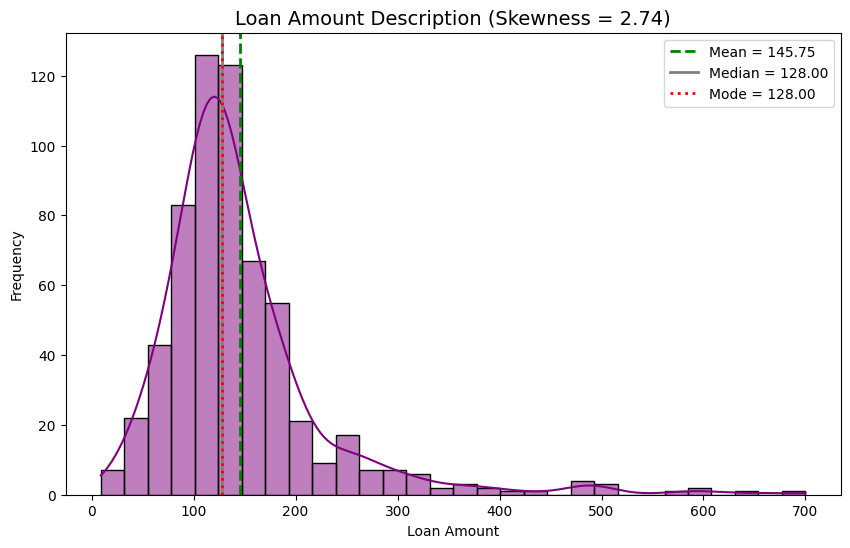

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(loan_amount, bins=30, kde=True, color="purple")

# Add vertical lines
plt.axvline(loan_amount_mean, color='green', linestyle='--', linewidth=2, label=f'Mean = {loan_amount_mean:.2f}')
plt.axvline(loan_amount_median, color='grey', linestyle='-', linewidth=2, label=f'Median = {loan_amount_median:.2f}')
plt.axvline(loan_amount_mode, color='red', linestyle=':', linewidth=2, label=f'Mode = {loan_amount_mode:.2f}')

# Add title and skewness
plt.title(f"Loan Amount Description (Skewness = {loan_amount_skew:.2f})", fontsize=14)
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [25]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
num = df_train[num_cols]
z_manual = (num - num.mean()) / num.std(ddof=0) # ddof=0 for population std
z_abs = z_manual.abs()
z_df_manual = pd.DataFrame(z_abs, columns=num_cols, index=df.index)

outlier_mask_manual = (z_df_manual > 3).any(axis=1)
print("Outliers per column (manual):\n", (z_df_manual > 3).sum())

Outliers per column (manual):
 ApplicantIncome       8
CoapplicantIncome     6
LoanAmount           15
Loan_Amount_Term     12
Credit_History        0
dtype: int64


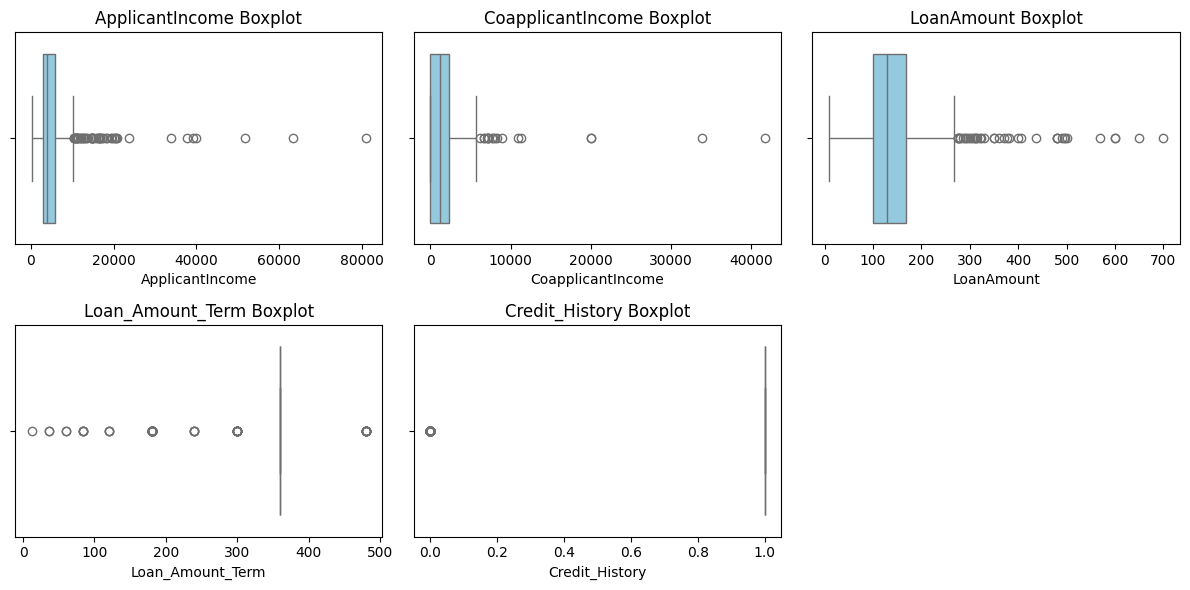

In [26]:
plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()

In [27]:
# comparing zscore and IQR to decide best fit moving forward with the data
z_threshold = 3
outliers_z = (z_df_manual > z_threshold).sum()
# outliers_z = (np.abs(z_manual(df[numeric_cols])) > z_threshold).sum()

numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
outliers_iqr = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers_iqr[col] = ((df[col] < lower) | (df[col] > upper)).sum()

print("Z-score outliers count:\n", outliers_z)
print("\nIQR outliers count:\n", outliers_iqr)

Z-score outliers count:
 ApplicantIncome       8
CoapplicantIncome     6
LoanAmount           15
Loan_Amount_Term     12
Credit_History        0
dtype: int64

IQR outliers count:
 {'ApplicantIncome': np.int64(50), 'CoapplicantIncome': np.int64(18), 'LoanAmount': np.int64(39), 'Loan_Amount_Term': np.int64(88), 'Credit_History': np.int64(89)}


In [28]:
df_train_copy = df_train.copy()

In [29]:
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
for col in numeric_cols:
    Q1 = df_train_copy[col].quantile(0.25)
    Q3 = df_train_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_train_copy[col] = np.clip(df_train_copy[col], lower_bound, upper_bound)

print("Outliers handled using IQR clipping successfully.")

Outliers handled using IQR clipping successfully.


In [30]:
clip_numeric_df = df_train_copy.select_dtypes(include='number')
clip_numeric_df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849.0,0.0,128.0,360.0,1.0
1,4583.0,1508.0,128.0,360.0,1.0
2,3000.0,0.0,66.0,360.0,1.0
3,2583.0,2358.0,120.0,360.0,1.0
4,6000.0,0.0,141.0,360.0,1.0


In [31]:
summary = clip_numeric_df.describe(percentiles=[0.10, 0.25, 0.50, 0.75]).T

summary['range'] = summary['max'] - summary['min']
summary['variance'] = clip_numeric_df.var()
summary['skew'] = clip_numeric_df.skew()
summary['mode'] = clip_numeric_df.mode().iloc[0]
summary['coeff_var'] = (summary['std'] / summary['mean']) * 100

summary['IQR'] = summary['75%'] - summary['25%']

summary['Outlier Lower'] = summary['25%'] - 1.5 * summary['IQR']
summary['Outlier Upper'] = summary['75%'] + 1.5 * summary['IQR']
summary['kurtosis'] = clip_numeric_df.kurtosis()

summary = summary.round(3)

print(summary)

                   count      mean       std    min     10%      25%     50%  \
ApplicantIncome    614.0  4617.112  2479.852  150.0  2216.1  2877.50  3812.5   
CoapplicantIncome  614.0  1419.702  1624.606    0.0     0.0     0.00  1188.5   
LoanAmount         614.0   137.366    55.780    9.0    72.3   100.25   128.0   
Loan_Amount_Term   614.0   342.410    64.429   12.0   300.0   360.00   360.0   
Credit_History     614.0     0.855     0.352    0.0     0.0     1.00     1.0   

                       75%        max      range     variance   skew  \
ApplicantIncome    5795.00  10171.250  10021.250  6149664.596  1.040   
CoapplicantIncome  2297.25   5743.125   5743.125  2639344.305  1.013   
LoanAmount          164.75    261.500    252.500     3111.380  0.684   
Loan_Amount_Term    360.00    480.000    468.000     4151.048 -2.402   
Credit_History        1.00      1.000      1.000        0.124 -2.022   

                       mode  coeff_var      IQR  Outlier Lower  Outlier Upper  \
Appli

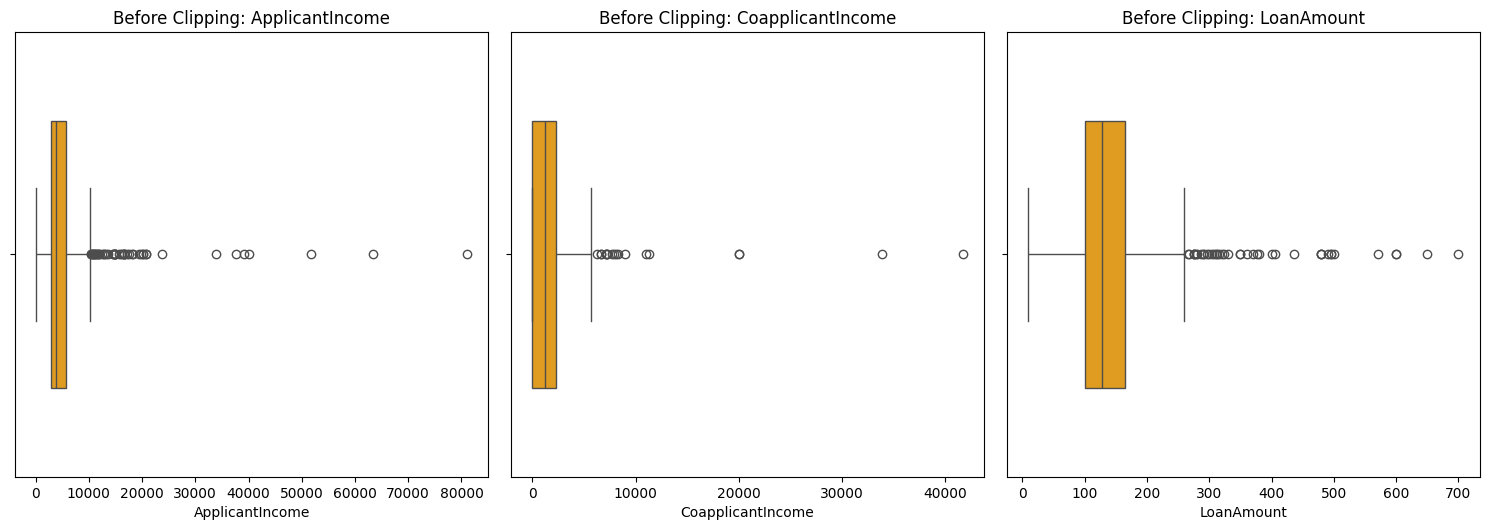

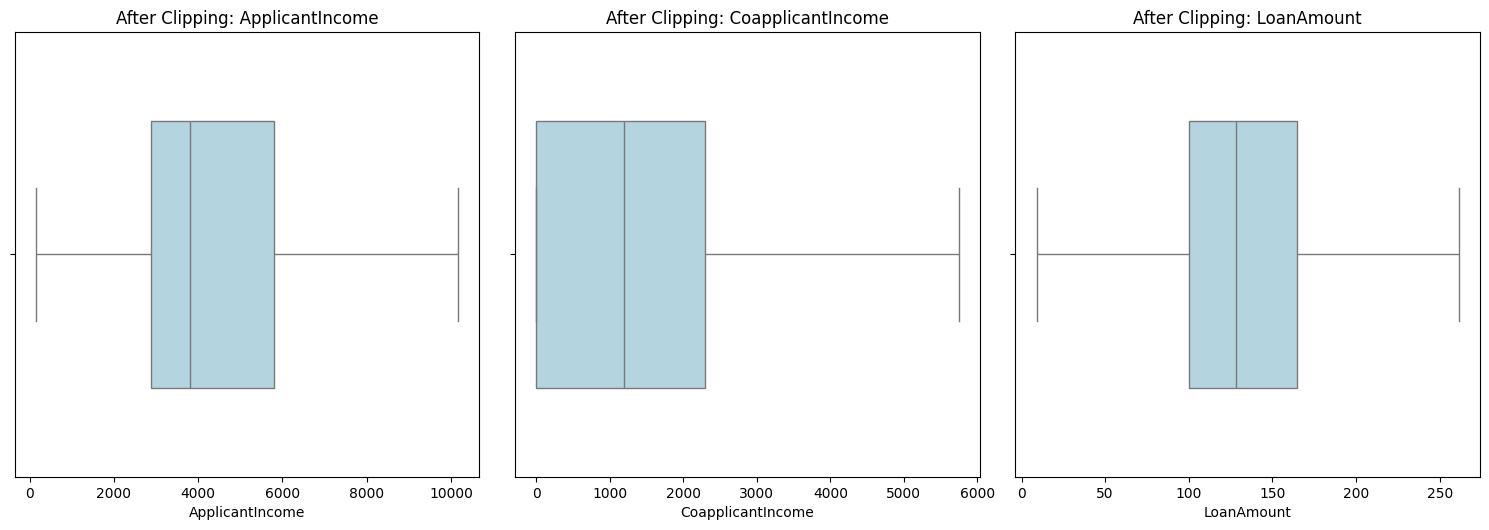

In [32]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_train[col], color='orange', width=0.6)
    plt.title(f'Before Clipping: {col}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_train_copy[col], color='lightblue', width=0.6)
    plt.title(f'After Clipping: {col}')

plt.tight_layout()
plt.show()

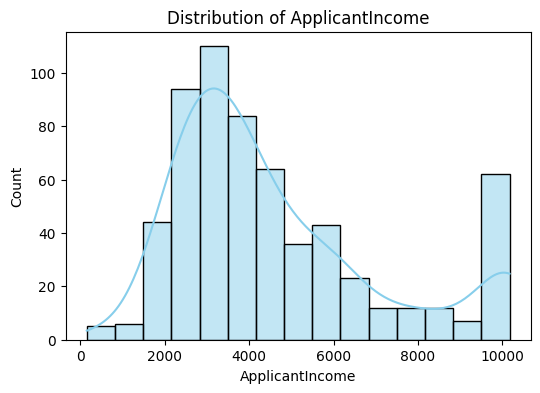

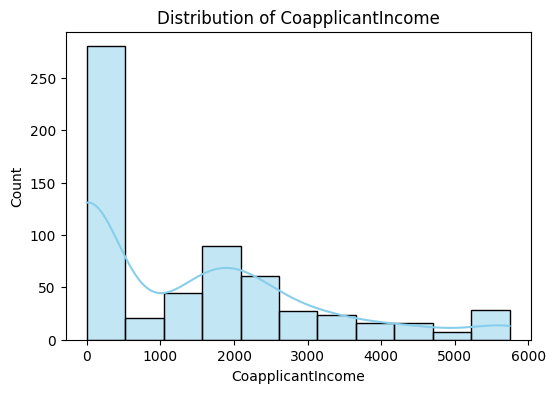

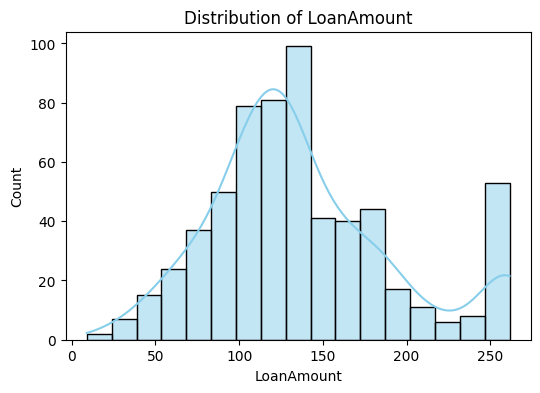

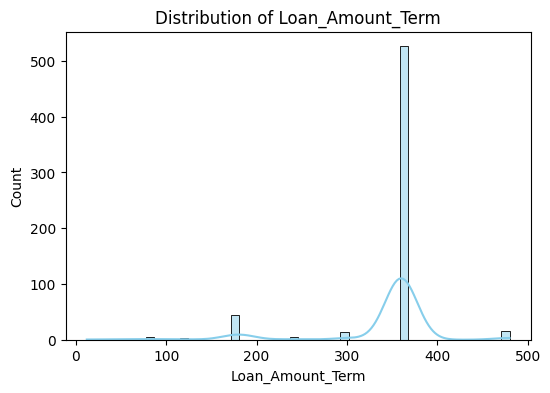

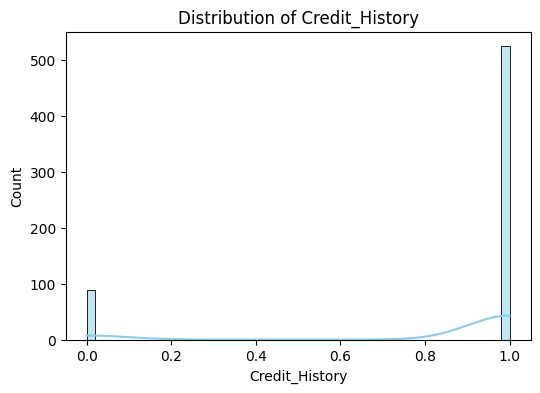

In [33]:
for col in clip_numeric_df:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_train_copy[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

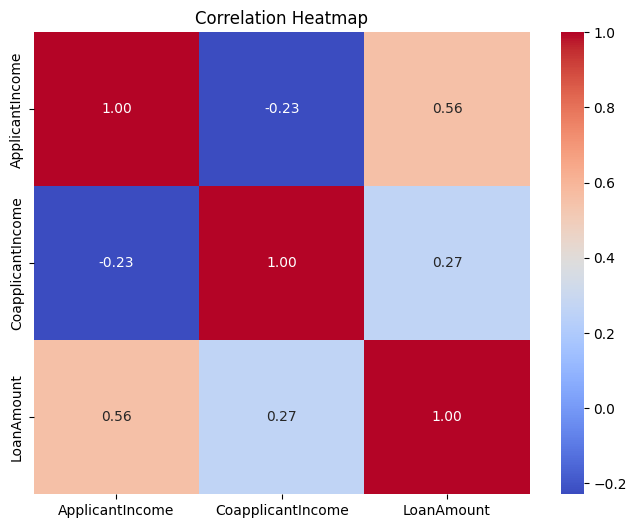

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_train_copy[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [35]:
df_train_copy.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y


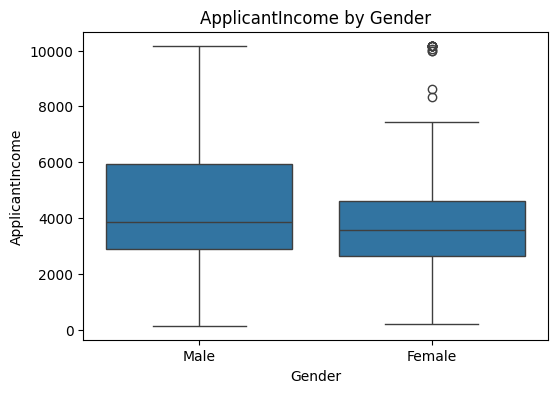

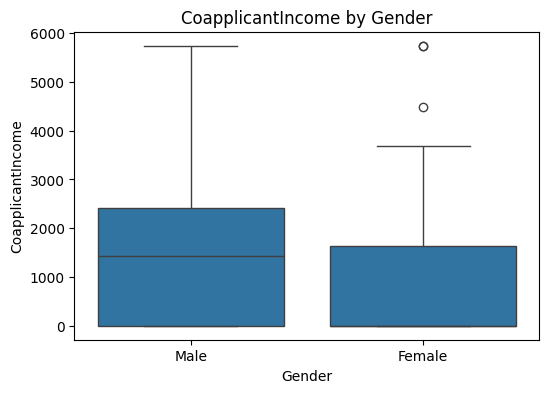

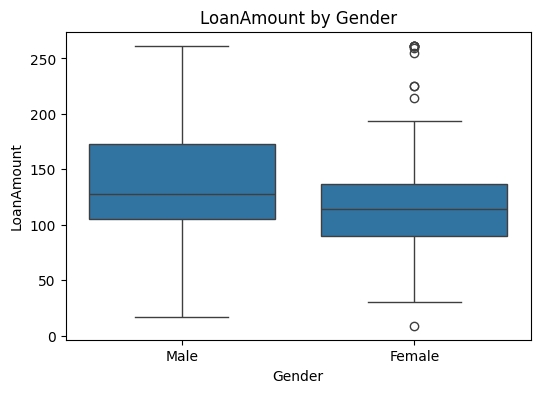

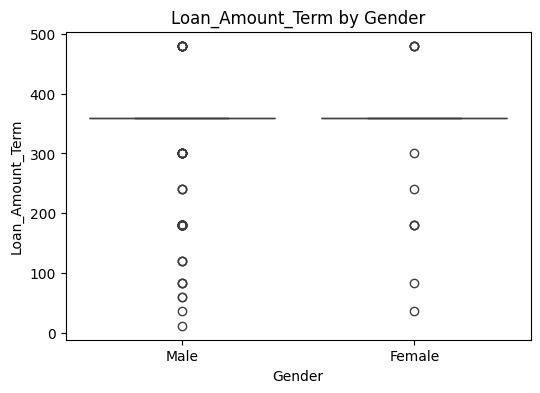

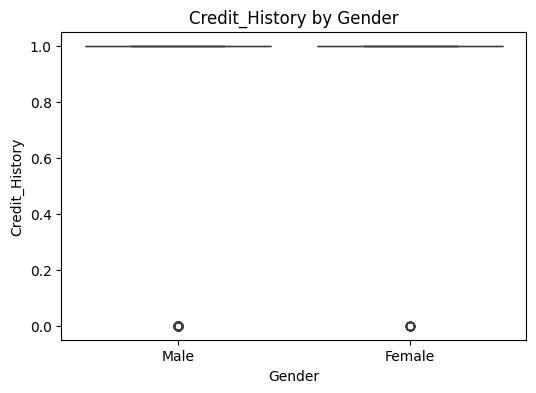

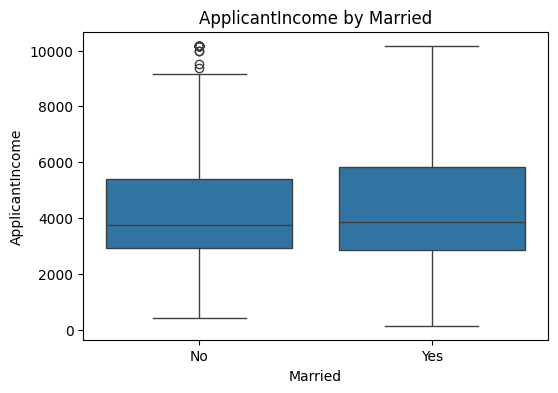

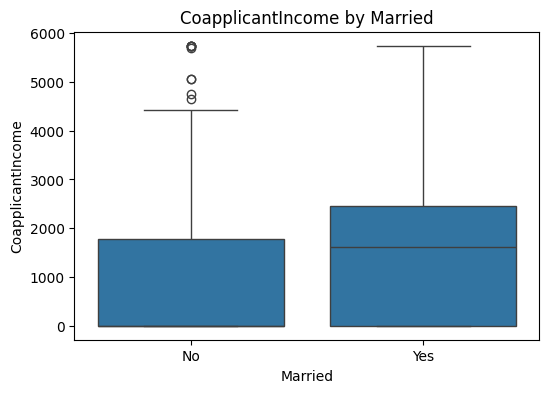

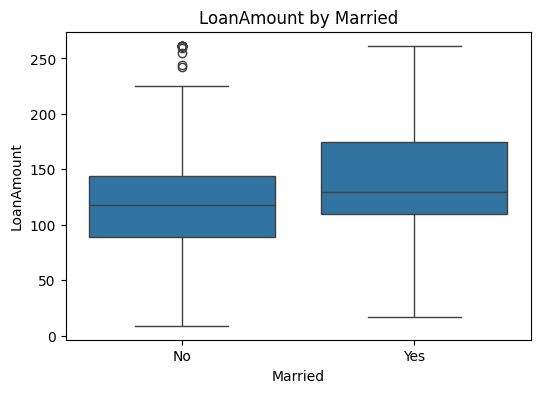

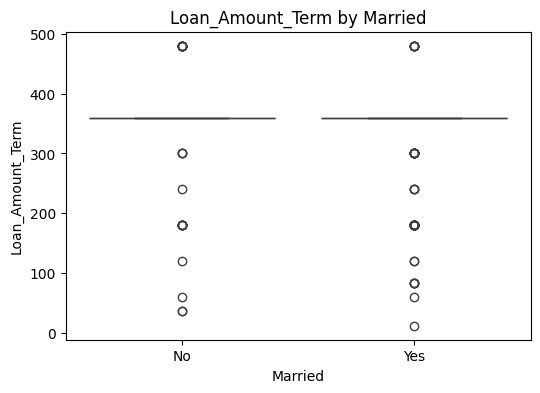

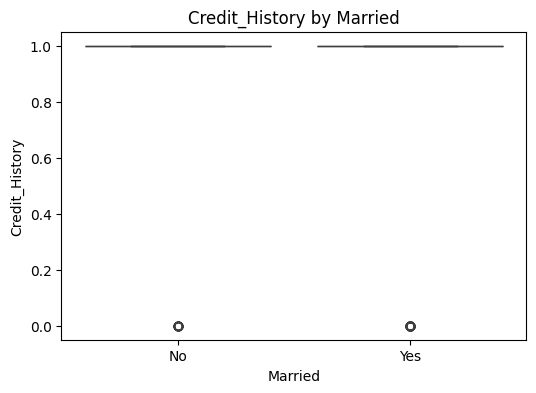

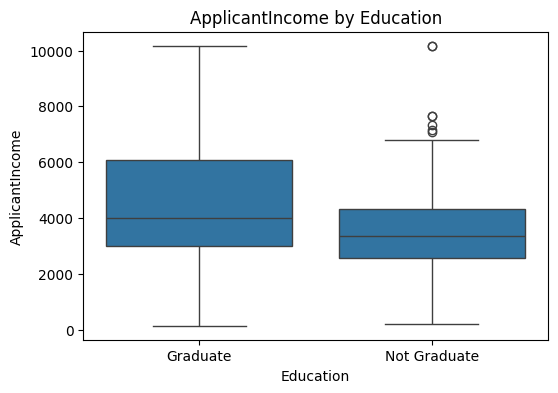

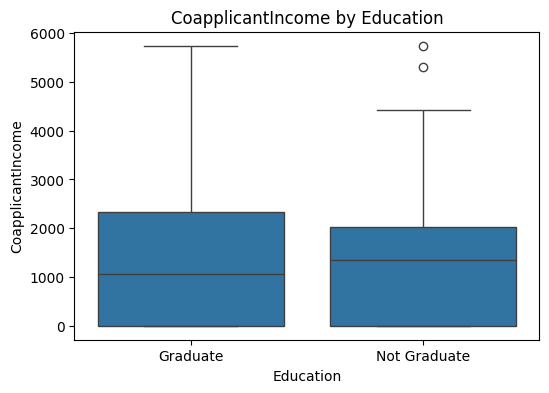

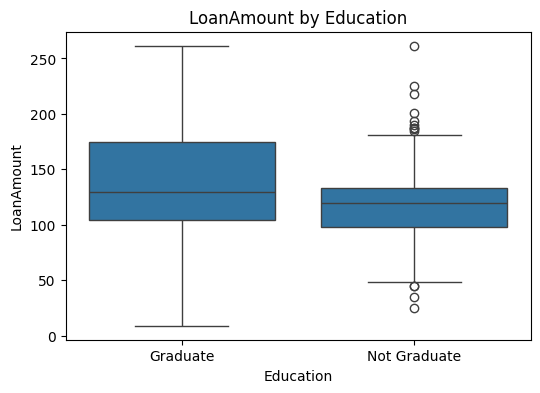

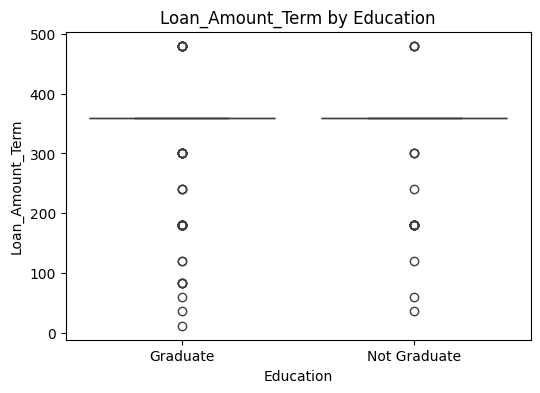

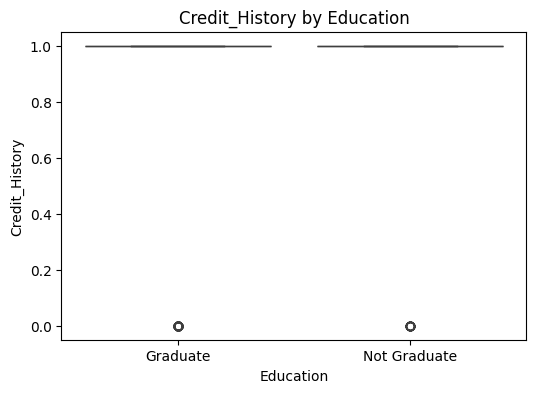

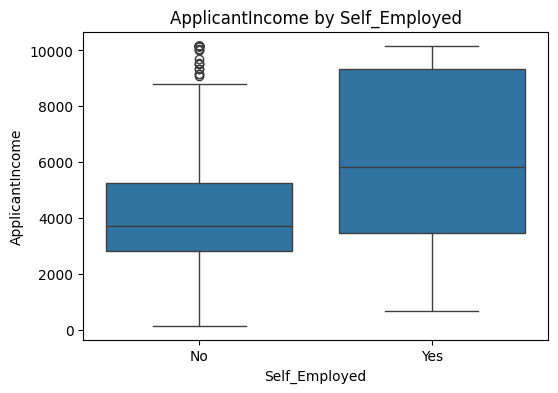

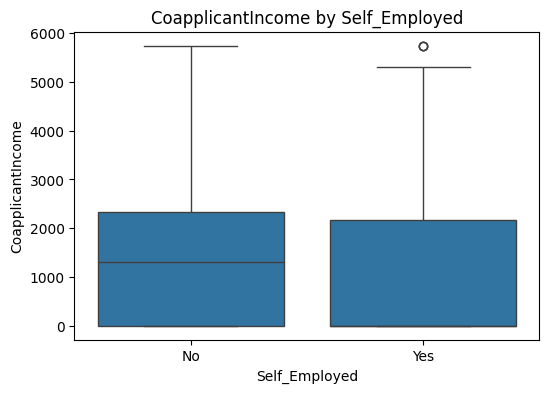

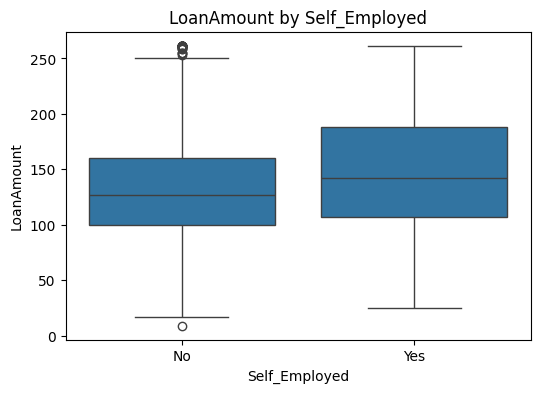

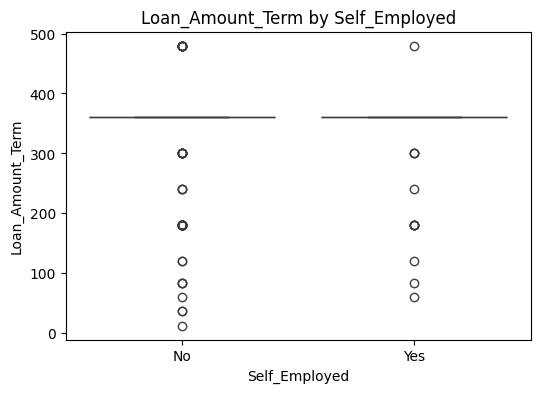

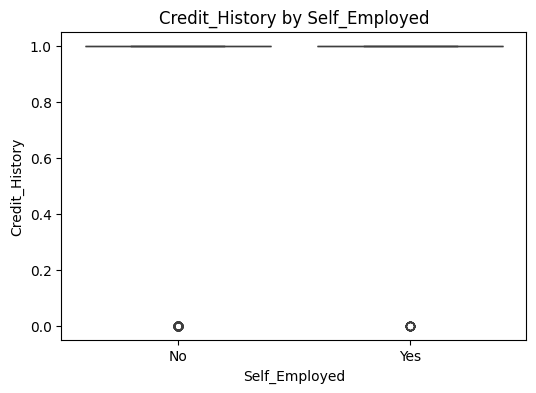

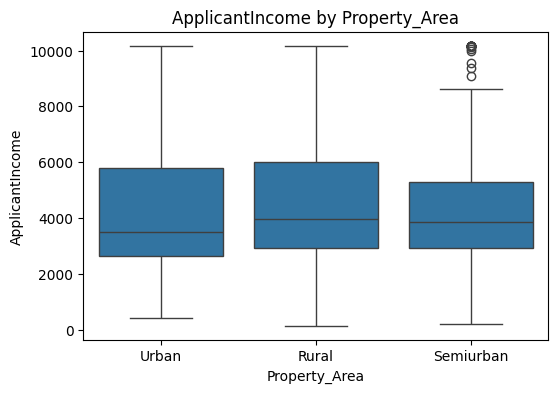

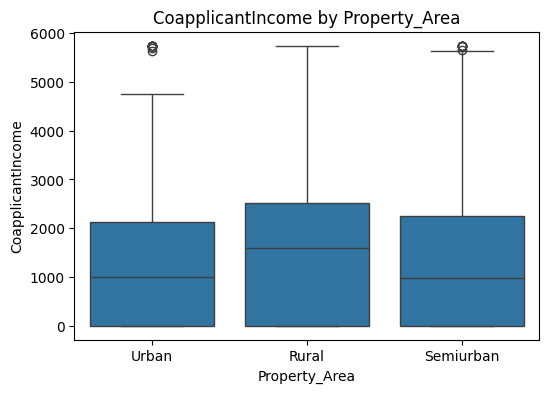

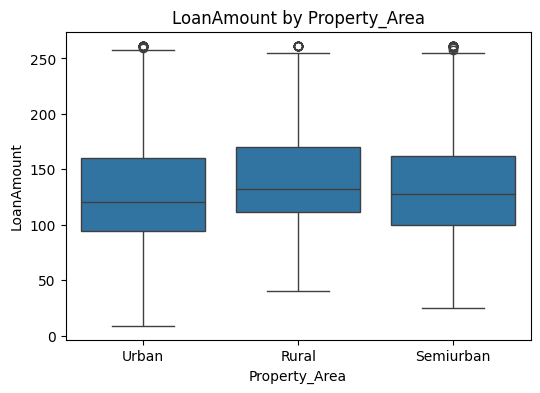

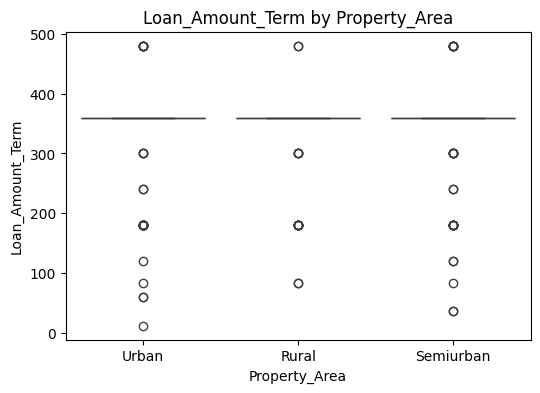

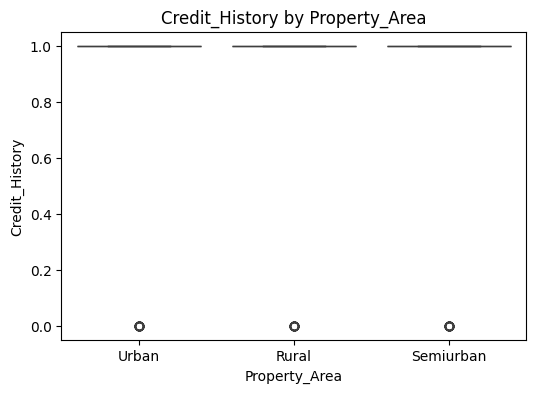

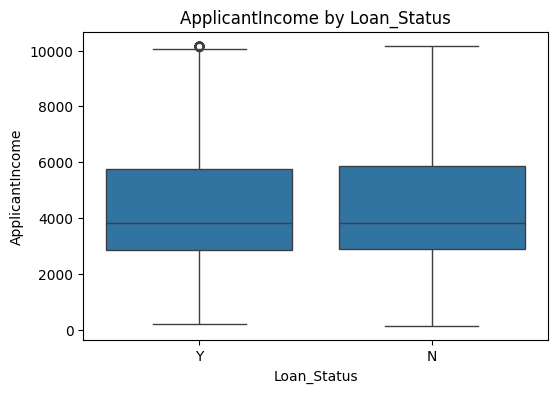

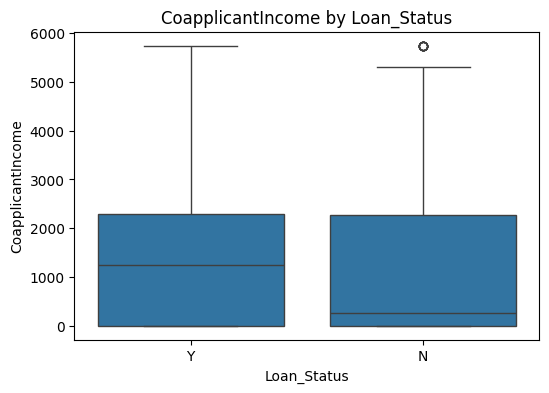

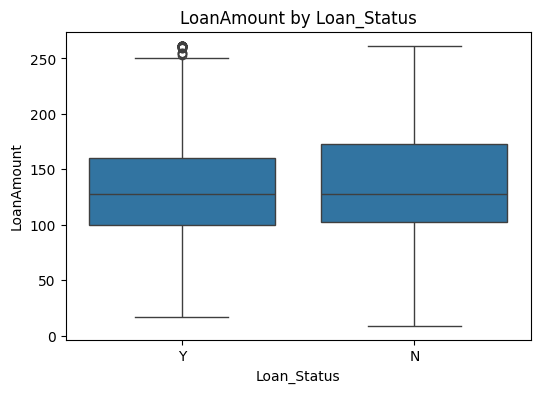

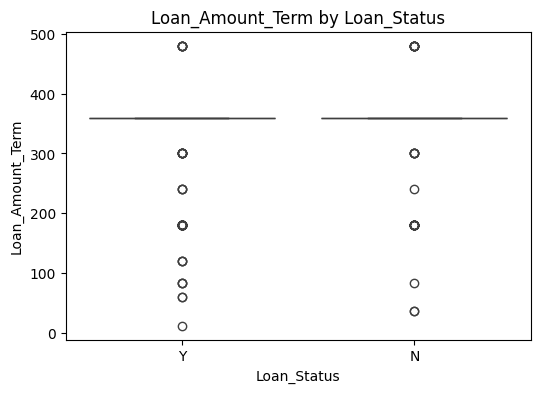

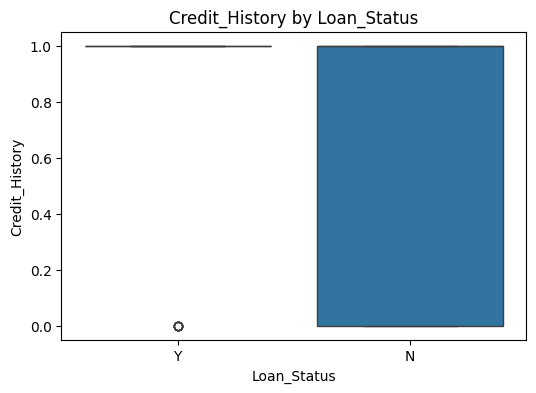

In [36]:
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
cate_cols = df_train_copy[categorical_cols]

for cat in cate_cols:
    for num in clip_numeric_df:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=cat, y=num, data=df_train_copy)
        plt.title(f'{num} by {cat}')
        plt.show()

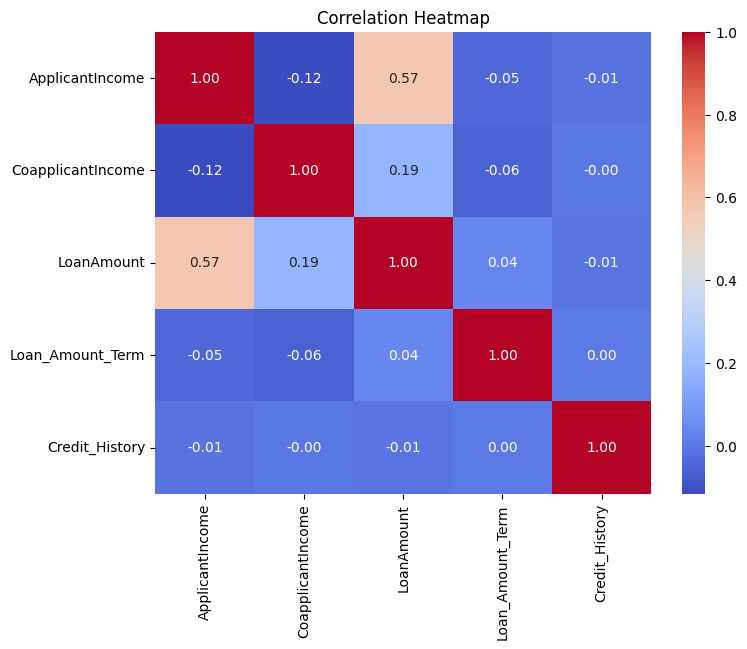

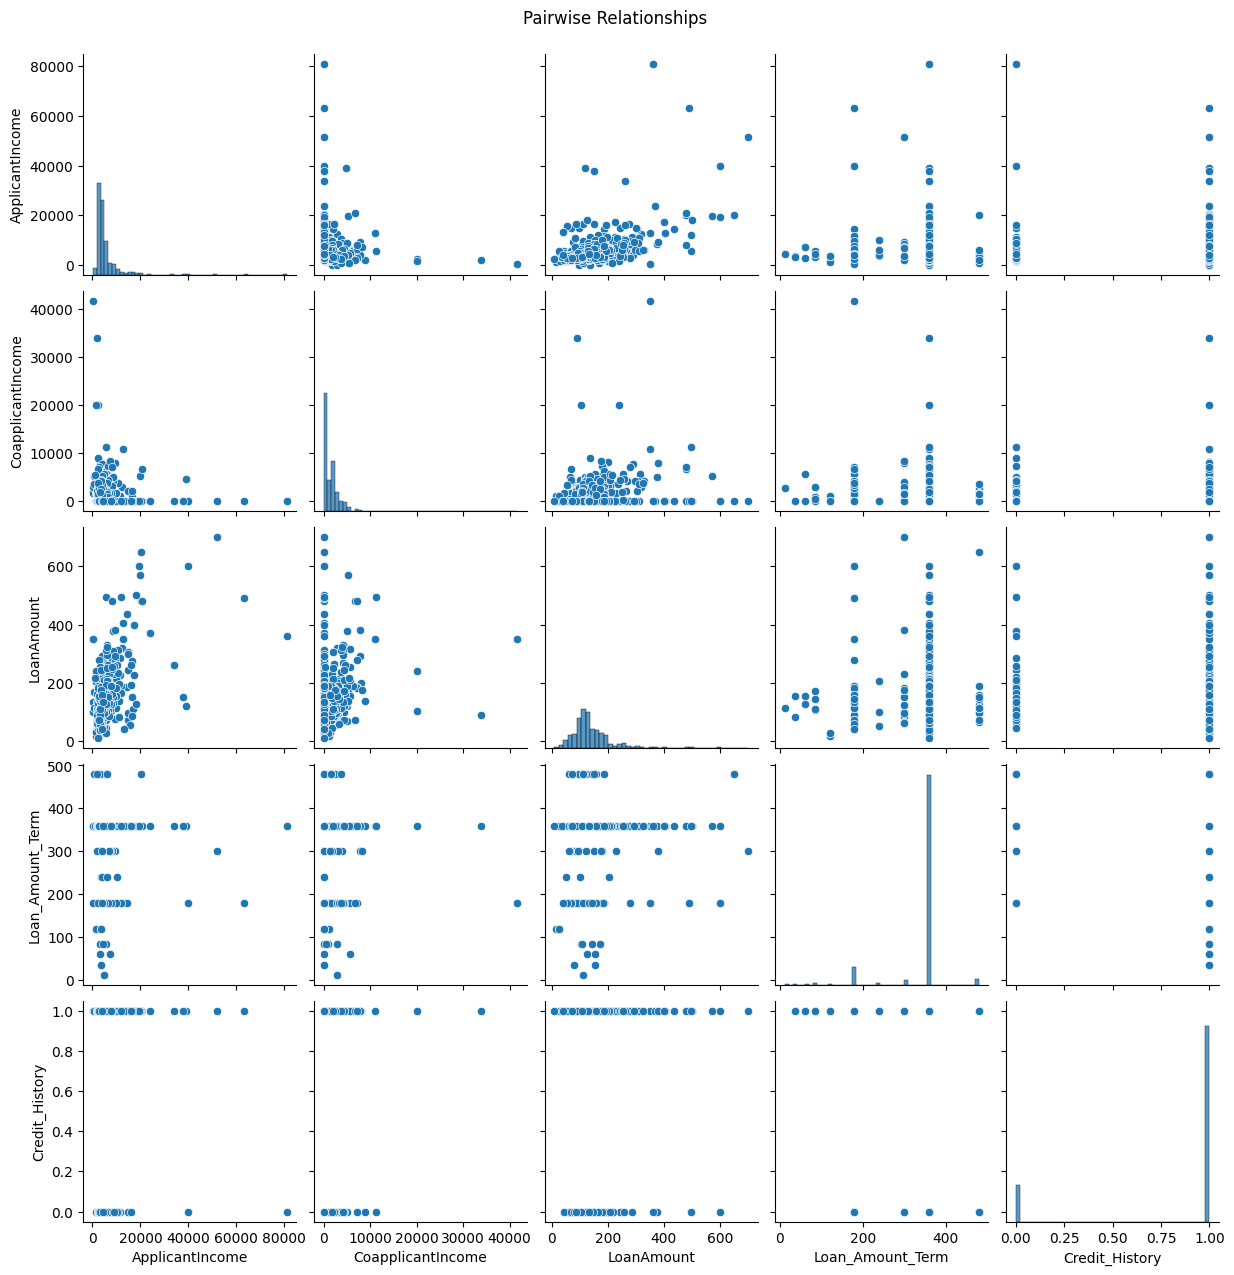

In [37]:
# Correlation matrix
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot for relationship patterns
sns.pairplot(df[num_cols])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()